In [1]:
# %% Imports & numerics
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from multiprocessing import Pool, cpu_count

import math
erf = np.vectorize(math.erf, otypes=[float])

NPROC = max(1, cpu_count() - 1)
trapz  = np.trapz
_EPS   = 1e-300  # To avoid 1/0

In [ ]:
# %% Constants & simple solar profiles
R_sun_cm = 6.957e10

c_kms = 299_792.458
def kms_to_c(v_kms): return v_kms / c_kms
def c_to_kms(v_c):   return v_c * c_kms

# Escape speeds (core→surface)
v_esc_core_kms = 1380.0
v_esc_surf_kms = 617.0
def vesc_of_r(r_cm):
    x = r_cm / R_sun_cm
    v_kms = v_esc_core_kms*(1.0 - x*x) + v_esc_surf_kms*(x*x)
    return kms_to_c(v_kms)

# Solar profiles
n_e0   = 6.0e25
T0_keV = 1.30
def shape_r(r_cm):
    x = r_cm / R_sun_cm
    return (1.0 - x*x)**2
def n_e_of_r(r_cm):  return n_e0 * shape_r(r_cm)
def T_of_r(r_cm):    return T0_keV * (0.7 + 0.3*shape_r(r_cm))
def n_p_of_r(r_cm):  return (10.0/12.0) * n_e_of_r(r_cm)
def n_He_of_r(r_cm): return ( 1.0/12.0) * n_e_of_r(r_cm)

# Target masses
m_e_keV  = 511.0
m_p_keV  = 938_272.0813
m_He_keV = 3_727_300.0
m_p_GeV = m_p_keV * 1e-6

In [3]:
# %% Halo PDF (Sun frame), 1D speed distribution
rho0_GeVcm3  = 0.30
rho0_keVcm3  = rho0_GeVcm3 * 1e6

v0_kms, v_sun_kms, v_esc_gal_kms = 220.0, 232.0, 544.0
v0, v_sun, v_esc_gal = map(kms_to_c, [v0_kms, v_sun_kms, v_esc_gal_kms])
vbar_halo = v0 * np.sqrt(8.0/np.pi)

def speed_pdf_raw(u):
    u = np.asarray(u, dtype=np.float64)
    out = np.zeros_like(u)
    a = (u - v_sun)**2/(v0*v0)
    b = (u + v_sun)**2/(v0*v0)
    c = (v_esc_gal*v_esc_gal)/(v0*v0)
    pref = u / (np.sqrt(np.pi)*v0*v_sun + _EPS)
    m1 = (u >= 0) & (u <  max(v_esc_gal - v_sun, 0.0))
    m2 = (u >= max(v_esc_gal - v_sun, 0.0)) & (u <  (v_esc_gal + v_sun))
    out[m1] = pref[m1] * (np.exp(-a[m1]) - np.exp(-b[m1]))
    out[m2] = pref[m2] * (np.exp(-a[m2]) - np.exp(-c))
    return out

def make_speed_pdf_grid(Nu=64):
    umax  = v_esc_gal + v_sun
    ugrid = np.linspace(0.0, umax, Nu, dtype=np.float64)
    g_raw = speed_pdf_raw(ugrid)
    norm  = trapz(g_raw, ugrid)
    g_pdf = np.where(norm > 0, g_raw/norm, g_raw)
    return ugrid, g_pdf

In [4]:
# %% Vector-portal thermal target y_th and σχT(mχ) in the contact limit
# Benchmarks as in the paper (α_D=0.5, m_{A'}/mχ=3)
alpha_em = 1/137.035999084
GEV2_TO_CM2 = 0.389379e-27  

def y_th(mchi_GeV, y0=1e-10, m0_GeV=0.1):
    return y0 * (mchi_GeV/m0_GeV)**2

Z_map = {'e': 1.0, 'p': 1.0, 'He': 2.0} 

def sigma_chiT_contact_thermal(mchi_GeV, mT_keV, Z):
    mT_GeV = mT_keV * 1e-6
    mu = (mchi_GeV*mT_GeV) / (mchi_GeV + mT_GeV + 1e-300)
    y  = y_th(mchi_GeV)
    sigma_GeV2 = 16.0*np.pi*alpha_em*(Z**2)*y*(mu*mu)/(mchi_GeV**4)
    return sigma_GeV2 * GEV2_TO_CM2  

In [5]:
# %% Analytic Γ_DM with ESCAPE projector  (correct units: include q/p0^2 in the integrand)
def gamma_dm_q_erf_escaped_per_sigma_nt(r_cm, vchi, mchi_keV, mT_keV, delta_keV, qN=160):
    """
    Γ_{χT} per (n_T σ_tot): analytic q-integral with an angular ESCAPE projector.
      cosθ ∈ [-1, cosθ_up(q)],    cosθ_up = [k^2 + q^2 - (mχ v_esc)^2]/(2 k q).
    Returns a quantity with units of velocity (c=1), i.e. ~ v_th × (dimensionless shape).

    IMPORTANT: the q–integrand must be (q/p0^2)[erf(A) - erf(B)] so that the
    integral is dimensionless; the prefactor gives the velocity scale.
    """
    if vchi <= 0.0:
        return 0.0

    # thermal and kinematic scales (keV and c-units)
    T_keV = T_of_r(r_cm)                       # keV
    p0    = np.sqrt(2.0 * mT_keV * T_keV)      # keV
    k     = mchi_keV * vchi                    # keV

    mu    = mT_keV / (mchi_keV + _EPS)         # m_T / m_χ   (dimensionless)
    mu_p  = 0.5 * (1.0 + mu)                   # (1+μ)/2
    vesc  = vesc_of_r(r_cm)

    # physical q-range for escaping final states
    qmin = abs(k - mchi_keV * vesc)
    qmax = k + mchi_keV * vesc
    if not (qmax > qmin):
        return 0.0

    # q-grid (avoid exactly q=0 because of 1/q terms)
    q0 = max(qmin, 1e-30)
    q  = np.linspace(q0, qmax, int(qN))

    # escape cap in the angular integral
    cos_up = (k*k + q*q - (mchi_keV*vesc)**2) / (2.0*q*k + _EPS)
    cos_up = np.clip(cos_up, -1.0, 1.0)

    # arguments of the error functions
    atop = (mu_p*q + (mT_keV*delta_keV)/q + mu*k*cos_up) / (p0 + _EPS)
    abot = (mu_p*q + (mT_keV*delta_keV)/q - mu*k)        / (p0 + _EPS)

    # prefactor:  (√π p0)/(2 μ k)  = √(π/2) * (v_th / vχ)
    pref = (np.sqrt(np.pi) * p0) / (2.0 * (mu*k + _EPS))

    # ---- corrected integrand: dimensionless ----
    integrand = (q / (p0*p0)) * (erf(atop) - erf(abot))

    val = pref * trapz(integrand, q)
    return float(val) if (np.isfinite(val) and val > 0.0) else 0.0

In [6]:
# %% Total escaping flux (Sun frame)
def flux_esc_total(mchi_keV, delta_keV, *,
                   m_t_keV, n_t_of_r, sigma_tot,
                   Nr=24, qN=160, Nvinf=48, chord_avg=True):
    """
    Φ_esc = Φ_halo * σ_tot * ∫_0^{R☉} path(r) n_T(r) ⟨ Γ_DM^esc(k,r)/vχ ⟩_halo .
    """
    Phi_halo = (rho0_keVcm3/(mchi_keV + _EPS)) * (vbar_halo * 2.99792458e10)
    u_grid, g_pdf = make_speed_pdf_grid(Nu=max(8, int(Nvinf)))

    r_grid = np.linspace(0.0, R_sun_cm, Nr)
    dr   = (R_sun_cm / max(Nr,1))
    path = 2.0*dr if chord_avg else dr

    total_col = 0.0
    for r in r_grid:
        vesc_r = vesc_of_r(r)
        vchi = np.sqrt(u_grid*u_grid + vesc_r*vesc_r)
        gam  = np.array([gamma_dm_q_erf_escaped_per_sigma_nt(r, vc, mchi_keV, m_t_keV, delta_keV, qN=qN)
                         for vc in vchi], dtype=np.float64)
        col = trapz(g_pdf * (gam/(vchi + _EPS)), u_grid)
        total_col += path * n_t_of_r(r) * col   

    return Phi_halo * sigma_tot * total_col

In [7]:
# %% Parallel map builder (now uses σχT(mχ) from y_th)
def _point_job_indexed(args):
    idx, mG, dG, m_t_keV, n_t_tag, gridspec = args
    m_keV = float(mG)*1e6
    d_keV = float(dG)*1e6
    n_t   = {"e": n_e_of_r, "p": n_p_of_r, "He": n_He_of_r}[n_t_tag]

    Z_T   = Z_map[n_t_tag]
    sigma_tot = sigma_chiT_contact_thermal(mG, m_t_keV, Z_T)  # cm^2

    val = flux_esc_total(m_keV, d_keV, m_t_keV=m_t_keV, n_t_of_r=n_t,
                         sigma_tot=sigma_tot, **gridspec)
    return idx, (0.0 if not np.isfinite(val) or val <= 0 else val)

def build_map_parallel(m_edges_GeV, d_edges_GeV, *, m_t_keV, n_t_tag,
                       gridspec, nproc=None, progress=True):
    m_cent = np.sqrt(m_edges_GeV[:-1]*m_edges_GeV[1:])
    d_cent = np.sqrt(d_edges_GeV[:-1]*d_edges_GeV[1:])
    tasks = [(i_m*len(d_cent)+i_d, mG, dG, m_t_keV, n_t_tag, gridspec)
             for i_m, mG in enumerate(m_cent) for i_d, dG in enumerate(d_cent)]

    if nproc is None:
        nproc = max(1, cpu_count()//2)

    Z_flat = np.zeros(len(tasks), dtype=np.float64)
    step = max(1, len(tasks)//40)
    with Pool(processes=nproc) as P:
        for cnt, (idx, val) in enumerate(
                P.imap_unordered(_point_job_indexed, tasks,
                                 chunksize=max(1, len(tasks)//(50*nproc))), start=1):
            Z_flat[idx] = val
            if progress and (cnt % step == 0 or cnt == len(tasks)):
                print(f"\r[{n_t_tag}] {cnt}/{len(tasks)}", end="", flush=True)
    if progress: print()
    return m_cent, d_cent, Z_flat.reshape(len(m_cent), len(d_cent))

In [8]:
# %% Plotting helper
def delta_bg_line_with_proton(mchi_GeV):
    beta = (v_esc_gal_kms + v_sun_kms) / c_kms
    mu   = (mchi_GeV * m_p_GeV) / (mchi_GeV + m_p_GeV + 1e-300)
    return 0.5 * mu * beta * beta

def draw_panel(ax, m_edges, d_edges, Z, title, pct=(2,98), *,
               show_bg=True, annotate_bg=False):
    Zplot = Z.T if Z.shape == (len(m_edges)-1, len(d_edges)-1) else Z
    good  = np.isfinite(Zplot) & (Zplot > 0)
    if np.any(good):
        vmin = np.nanpercentile(Zplot[good], pct[0])
        vmax = np.nanpercentile(Zplot[good], pct[1])
        vmin = max(vmin, 1e-99); vmax = max(vmax, vmin*10.0)
    else:
        vmin, vmax = 1e-30, 1e-20
    extent = (np.log10(m_edges[0]), np.log10(m_edges[-1]),
              np.log10(d_edges[0]), np.log10(d_edges[-1]))
    im = ax.imshow(Zplot, origin="lower", aspect="auto",
                   extent=extent, norm=LogNorm(vmin=vmin, vmax=vmax), cmap="viridis")
    ax.set_xlabel(r'$\log_{10}(m_\chi\,[\mathrm{GeV}])$')
    ax.set_ylabel(r'$\log_{10}(\delta\,[\mathrm{GeV}])$')
    ax.set_title(title)

    if show_bg:
        m_vals = np.logspace(np.log10(m_edges[0]), np.log10(m_edges[-1]), 800)
        d_vals = delta_bg_line_with_proton(m_vals)
        mask   = (d_vals > 0) & np.isfinite(d_vals)
        ax.plot(np.log10(m_vals[mask]), np.log10(d_vals[mask]), 'k--', lw=2, alpha=0.95)
    return im

[e] 900/900
[p] 900/900
[He] 900/900


/tmp/ipykernel_265514/3518153376.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0.03, 0.90, 0.97])


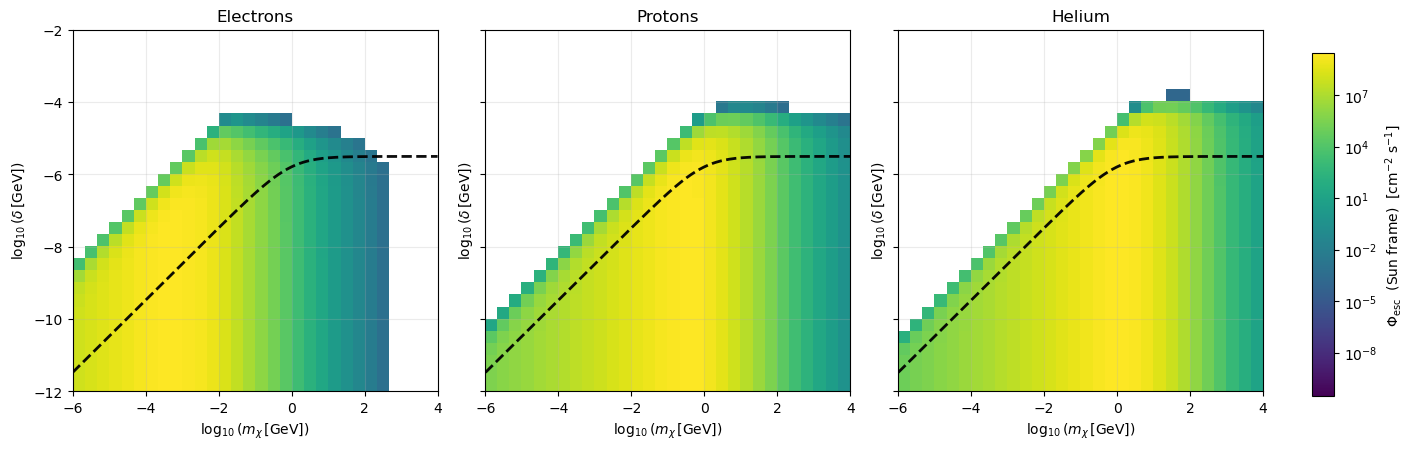

In [9]:
# %% Run & plot
Nm, Nd = 30, 30
m_edges_GeV = np.logspace(-6.0, 4.0, Nm+1)
d_edges_GeV = np.logspace(-12.0, -2.0, Nd+1)

gridspec = dict(Nr=40, qN=320, Nvinf=128, chord_avg=True)

m_e,  d_e,  Z_e  = build_map_parallel(m_edges_GeV, d_edges_GeV, m_t_keV=m_e_keV,  n_t_tag="e",
                                      gridspec=gridspec, nproc=NPROC, progress=True)
m_p,  d_p,  Z_p  = build_map_parallel(m_edges_GeV, d_edges_GeV, m_t_keV=m_p_keV,  n_t_tag="p",
                                      gridspec=gridspec, nproc=NPROC, progress=True)
m_He, d_He, Z_He = build_map_parallel(m_edges_GeV, d_edges_GeV, m_t_keV=m_He_keV, n_t_tag="He",
                                      gridspec=gridspec, nproc=NPROC, progress=True)

fig, axs = plt.subplots(1, 3, figsize=(14.8, 4.9), sharex=True, sharey=True)
im0 = draw_panel(axs[0], m_edges_GeV, d_edges_GeV, Z_e,  "Electrons")
im1 = draw_panel(axs[1], m_edges_GeV, d_edges_GeV, Z_p,  "Protons")
im2 = draw_panel(axs[2], m_edges_GeV, d_edges_GeV, Z_He, "Helium")

cax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
cb  = fig.colorbar(im2, cax=cax)
cb.set_label(r"$\Phi_{\rm esc}$  (Sun frame)  [cm$^{-2}$ s$^{-1}$]")

for ax in axs:
    ax.set_xlim(np.log10(m_edges_GeV[0]), np.log10(m_edges_GeV[-1]))
    ax.set_ylim(np.log10(d_edges_GeV[0]), np.log10(d_edges_GeV[-1]))
    ax.grid(alpha=0.25)

plt.tight_layout(rect=[0.03, 0.03, 0.90, 0.97])
plt.show()

/tmp/ipykernel_265514/1910978423.py:31: RuntimeWarning: divide by zero encountered in log10
  Zlog = np.where(Z > 0, np.log10(Z), np.nan)


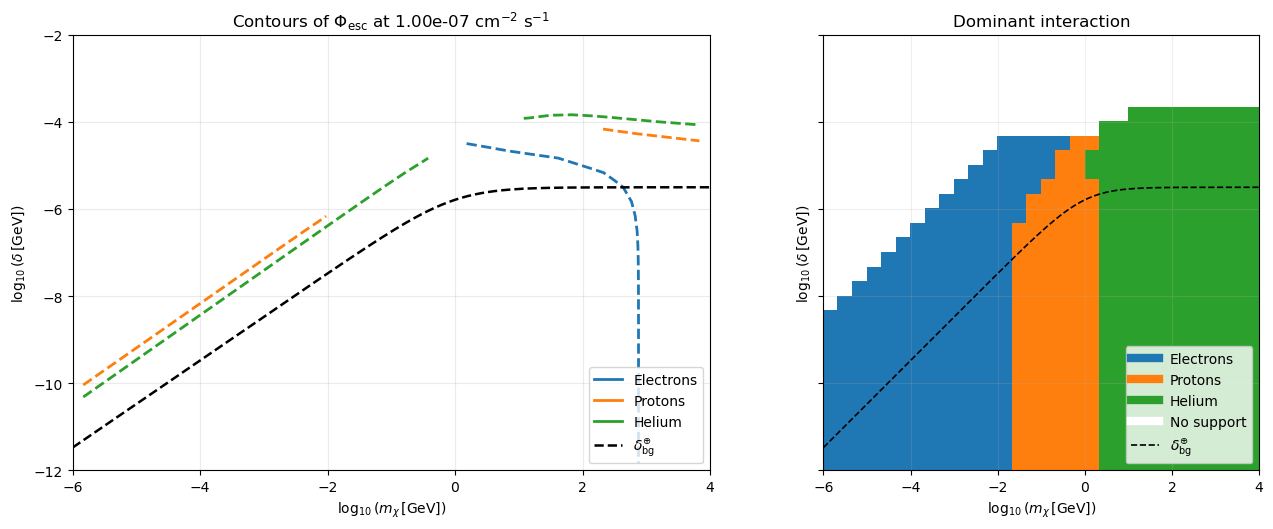

In [10]:
# %% Contour-comparison (fixed Φ_esc level) + dominance ("temperature") plots
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

mx_c = 0.5*(np.log10(m_edges_GeV[:-1]) + np.log10(m_edges_GeV[1:]))
dl_c = 0.5*(np.log10(d_edges_GeV[:-1]) + np.log10(d_edges_GeV[1:]))
MX, DL = np.meshgrid(mx_c, dl_c, indexing="ij")

m_p_GeV = m_p_keV * 1e-6
beta    = (v_esc_gal_kms + v_sun_kms) / c_kms
def delta_bg_line_with_proton(mchi_GeV):
    mu = (mchi_GeV * m_p_GeV) / (mchi_GeV + m_p_GeV + 1e-300)
    return 0.5 * mu * beta * beta

m_vals = np.logspace(np.log10(m_edges_GeV[0]), np.log10(m_edges_GeV[-1]), 800)
d_vals = delta_bg_line_with_proton(m_vals)
mask_bg = np.isfinite(d_vals) & (d_vals > 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.8, 5.4), sharex=True, sharey=True)

# Contour comparison at a single absolute flux level 
phi_level      = 1e-7      
auto_fraction  = 1e-3         

global_max = np.nanmax([np.nanmax(Z_e), np.nanmax(Z_p), np.nanmax(Z_He)])
if phi_level is None:
    phi_level = auto_fraction * global_max
lev_log = np.log10(phi_level)

def add_flux_contour(ax, Z, color, label):
    Zlog = np.where(Z > 0, np.log10(Z), np.nan)
    ax.contour(MX, DL, Zlog, levels=[lev_log], colors=[color], linewidths=2)
    ax.plot([], [], color=color, lw=2, label=label)  

add_flux_contour(ax1, Z_e,  'tab:blue',   'Electrons')
add_flux_contour(ax1, Z_p,  'tab:orange', 'Protons')
add_flux_contour(ax1, Z_He, 'tab:green',  'Helium')

ax1.plot(np.log10(m_vals[mask_bg]), np.log10(d_vals[mask_bg]), 'k--', lw=1.8,
         label=r'$\delta_{\rm bg}^{\oplus}$')

ax1.set_title(rf"Contours of $\Phi_{{\rm esc}}$ at {phi_level:.2e} cm$^{{-2}}$ s$^{{-1}}$")
ax1.set_xlabel(r'$\log_{10}(m_\chi\,[\mathrm{GeV}])$')
ax1.set_ylabel(r'$\log_{10}(\delta\,[\mathrm{GeV}])$')
ax1.grid(alpha=0.25)
ax1.set_xlim(np.log10(m_edges_GeV[0]), np.log10(m_edges_GeV[-1]))
ax1.set_ylim(np.log10(d_edges_GeV[0]), np.log10(d_edges_GeV[-1]))
ax1.legend(loc='lower right', frameon=True)

stack = np.stack([Z_e, Z_p, Z_He], axis=0)                 
stack = np.nan_to_num(stack, nan=0.0, posinf=0.0, neginf=0.0)

# True support: keep a cell if ANY channel has positive flux
support = np.any(stack > 0.0, axis=0)                     

# Dominant channel among {e, p, He}; ties go to first max automatically
dom = np.argmax(stack, axis=0)                             
dom = np.where(support, dom, -1)                         

cmap_dom = ListedColormap(['white', 'tab:blue', 'tab:orange', 'tab:green'])
bounds   = [-1, -0.5, 0.5, 1.5, 2.5]                       
norm     = BoundaryNorm(bounds, cmap_dom.N)

im = ax2.imshow(dom.T, origin='lower', interpolation='nearest',
                extent=(np.log10(m_edges_GeV[0]), np.log10(m_edges_GeV[-1]),
                        np.log10(d_edges_GeV[0]), np.log10(d_edges_GeV[-1])),
                cmap=cmap_dom, norm=norm)

ax2.plot(np.log10(m_vals[mask_bg]), np.log10(d_vals[mask_bg]), 'k--', lw=1.2)

ax2.set_title("Dominant interaction")
ax2.set_xlabel(r'$\log_{10}(m_\chi\,[\mathrm{GeV}])$')
ax2.set_ylabel(r'$\log_{10}(\delta\,[\mathrm{GeV}])$')
ax2.grid(alpha=0.20)

ax2.legend(handles=[
    Line2D([0],[0], color='tab:blue',   lw=6, label='Electrons'),
    Line2D([0],[0], color='tab:orange', lw=6, label='Protons'),
    Line2D([0],[0], color='tab:green',  lw=6, label='Helium'),
    Line2D([0],[0], color='white',      lw=6, label='No support'),
    Line2D([0],[0], color='k',          lw=1.2, ls='--', label=r'$\delta_{\rm bg}^{\oplus}$'),
], loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

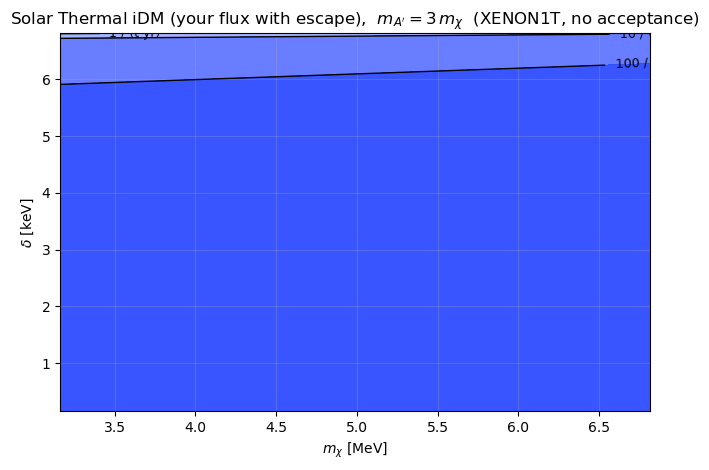

In [11]:
# === Fig. 6 (left) — build XENON1T iso-event-rate contours from your EXISTING Z_e (no acceptance) ===
# Assumes you already ran your flux code and have:
#   m_e (GeV), d_e (GeV), Z_e (Sun-surface escaping flux [cm^-2 s^-1])
# and the functions/constants already defined in your session:
#   sigma_chiT_contact_thermal(mchi_GeV, mT_keV, Z), m_e_keV, R_sun_cm
# This cell does NOT recompute Φ; it only post-processes Z_e → event rates at Earth and plots.

import numpy as np
import matplotlib.pyplot as plt

# ---- tiny helper: modified Bessel K_n (fallback if SciPy not present) ----
try:
    from scipy.special import kv as _Knu
except Exception:
    def _Knu(nu, x):
        # asymptotic for large x; good enough to keep F→1 at small δ and capture tilt
        x = np.asarray(x, dtype=float)
        base = np.sqrt(np.pi/(2.0*np.maximum(x, 1e-12))) * np.exp(-x)
        corr = 1.0 + (4.0*nu*nu - 1.0)/(8.0*np.maximum(x, 1e-12))
        return base*corr

# ---- detector & geometric constants (not in your flux module) ----
AU_cm       = 1.495978707e13
N_A         = 6.022_140_76e23     # mol^-1
A_Xe_gmol   = 131.293             # g/mol
Zfree_Xe    = 26                  # effective free/loosely-bound e− per Xe atom
SEC_PER_YR  = 365.25*24*3600.0
_EPS        = 1e-300

# ---- F enhancement (Eqs. 4.12–4.13) on a (mχ,δ) grid ----
def _F_enhancement_grid(_mchi_GeV, _delta_keV, T_eff_keV=1.30):
    """
    F = sqrt(1 + 2*δ/(μ <v^2>)),  with  <v^2> = (δ μ / mχ) * K2(x)/K1(x),
    x = δ m_e / (2 μ T_eff).  All energies in keV; velocities in c=1 units.
    """
    mchi_keV  = (np.asarray(_mchi_GeV)*1e6)[:, None]       # (Nm,1)
    delta_keV = (np.asarray(_delta_keV))[None, :]          # (1,Nd)
    mu_keV    = (mchi_keV*m_e_keV)/(mchi_keV + m_e_keV)    # (Nm,1)
    x         = (delta_keV*m_e_keV)/(2.0*mu_keV*T_eff_keV + _EPS)
    x         = np.maximum(x, 1e-12)
    K1 = _Knu(1, x); K2 = _Knu(2, x)
    v2 = (delta_keV*mu_keV/(mchi_keV + _EPS)) * (K2/np.maximum(K1, 1e-300))
    return np.sqrt(1.0 + (2.0*delta_keV)/(mu_keV*np.maximum(v2, _EPS) + _EPS))

# ---- select Fig. 6 (left) window from your existing grid ----
# Paper axes: mχ ∈ [1.5, 14] MeV, δ ∈ [0.1, 10] keV
_m_mask = (m_e >= 1.5e-3) & (m_e <= 14.0e-3)    # m_e in GeV
_d_keV  = d_e * 1e6
_d_mask = (_d_keV >= 0.1) & (_d_keV <= 10.0)

m_sub_GeV  = m_e[_m_mask]
d_sub_keV  = _d_keV[_d_mask]
Phi_surface_sub = Z_e[np.ix_(_m_mask, _d_mask)]             # Sun-surface flux [cm^-2 s^-1]

# ---- propagate flux to Earth (1/r^2) ----
Phi_earth_sub = Phi_surface_sub * (R_sun_cm/AU_cm)**2       # [cm^-2 s^-1] at 1 AU

# ---- detection microphysics on the (m,δ) grid ----
sigma_e_sub = sigma_chiT_contact_thermal(m_sub_GeV, m_e_keV, 1.0)[:, None]  # (Nm,1) cm^2
F_sub       = _F_enhancement_grid(m_sub_GeV, d_sub_keV)                     # (Nm,Nd)

# ---- convert flux → total rate (Eq. 4.15), NO acceptance ----
N_T_per_g   = N_A * Zfree_Xe / A_Xe_gmol
N_T_per_ton = N_T_per_g * 1.0e6
R_per_s     = N_T_per_ton * Phi_earth_sub * sigma_e_sub * F_sub   # events / s on 1 t
R_per_tyr   = R_per_s * SEC_PER_YR                                # events / (t·yr)

# ---- plot (linear axes, Fig.6-style shading and labels) ----
_MM, _DD = np.meshgrid(m_sub_GeV*1e3, d_sub_keV, indexing="ij")  # MeV, keV
_levels = (1.0, 10.0, 100.0)

fig, ax = plt.subplots(figsize=(6.6, 4.8))
# filled shading
valid_levels = [lv for lv in _levels if lv < np.nanmax(R_per_tyr)]
fill_levels  = [0.0] + valid_levels + [max(np.nanmax(R_per_tyr)*1.01,
                                           (valid_levels[-1] if valid_levels else 0.0)+1e-6)]
ax.contourf(_MM, _DD, R_per_tyr,
            levels=fill_levels,
            colors=["#d9ddff", "#9fb0ff", "#6076ff", "#2e4cff"][:len(fill_levels)-1],
            alpha=0.95)

if valid_levels:
    cs = ax.contour(_MM, _DD, R_per_tyr, levels=valid_levels, colors="k", linewidths=1.0)
    ax.clabel(cs, fmt={lv: f"{int(lv)} / (t·yr)" for lv in valid_levels}, inline=True, fontsize=9)

ax.set_xlabel(r"$m_\chi$ [MeV]")
ax.set_ylabel(r"$\delta$ [keV]")
ax.set_title(r"Solar Thermal iDM (your flux with escape),  $m_{A'}=3\,m_\chi$  (XENON1T, no acceptance)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()